# DL078 图神经网络与关系数据

对应S1。按顺序执行；先预测结果再看输出。数据和研究范围见lecture.md。本Notebook实际复跑全部实验，写入notebook_outputs，不覆盖课程参考输出。

In [1]:
from pathlib import Path
import json, sys
# Notebook应在本单元目录启动。
print("Python",sys.version.split()[0])
print("目录",Path.cwd())
if not Path("experiment.py").exists():
    raise RuntimeError("请在当前单元目录运行")

Python 3.12.14
目录 /workspace/scratch/1577d0a62398/course-batch-078-082/dl/units/078


## 先运行数值与边界测试
测试通过不等于科学假设成立，但失败时不要跳过。

In [2]:
import unittest
import test_experiment
# 使用显式unittest检查，不依赖可被-O移除的assert。
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=2).run(suite)
if not result.wasSuccessful():
    raise RuntimeError("测试失败，停止实验")

test_bad_shape (test_experiment.Tests.test_bad_shape) ... 

ok


test_consensus (test_experiment.Tests.test_consensus) ... 

ok


test_equivariance (test_experiment.Tests.test_equivariance) ... 

...

test_split (test_experiment.Tests.test_split) ... 

ok


test_training (test_experiment.Tests.test_training) ... 

ok


----------------------------------------------------------------------
Ran 11 tests in 0.082s

OK


## 完整复跑
参数、预测和数据都由本次运行重新生成；运行时长取决于机器。

In [3]:
from experiment import run
results=run("notebook_outputs")
print(json.dumps(results,ensure_ascii=False,indent=2))

{
  "gnn_val_mse": 0.00044004427091651893,
  "permutation_max_error": 1.1102230246251565e-16,
  "gnn_test_mse_seeds": [
    0.00047179090458007657,
    0.00045420332163911473,
    0.0004960669824831616
  ],
  "gnn_test_mse_mean": 0.00047402040290078426,
  "blind_val_mse": 0.10335783732427489,
  "blind_test_mse_seeds": [
    0.10225833649589879,
    0.10224843546870772,
    0.10222100338490492
  ],
  "blind_test_mse_mean": 0.10224259178317048,
  "seconds": 1.2993765120008902,
  "seed_data": 78,
  "train_graphs": 100,
  "val_graphs": 25,
  "test_graphs": 25,
  "steps": 1600,
  "hidden": 12
}


## 手算邻域平均

In [4]:
import numpy as np
from experiment import transition
# 0–1–2链：先加自环，再除以每行的邻居数。
a = np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=float)
x = np.array([[1.],[2.],[4.]])
print("P =", transition(a))
print("PX =", (transition(a) @ x).ravel())

P = [[0.5        0.5        0.        ]
 [0.33333333 0.33333333 0.33333333]
 [0.         0.5        0.5       ]]
PX = [1.5        2.33333333 3.        ]


## 重编号不是更换物理图

In [5]:
from experiment import features, init, predict
# 行与列必须同时改变；右边则只重排节点输出。
p = [2,0,1]
w = init(4)
left = predict(features(a[p][:,p], x[p]), w)
right = predict(features(a,x),w)[p]
print("最大置换误差", np.max(np.abs(left-right)))

最大置换误差 2.220446049250313e-16


## 过平滑诊断

In [6]:
d = np.load("notebook_outputs/data.npz", allow_pickle=False)
# 这是纯P传播，不能说训练了40层深网。
print("0、10、40层节点方差", d["smooth_variance"][[0,10,40]])
print("已知机制干预效应", d["intervention_effect"].ravel())

0、10、40层节点方差 [1.91508664e+00 1.97203321e-03 4.28303184e-09]
已知机制干预效应 [0.46480695 0.33729472 0.         0.         0.         0.
 0.         0.00225538]


## 阅读输出与研究边界
下面显示课程参考图；数值来自本次复跑results，两者的来源请分清。最后用自己的话回答实验册的限制问题。

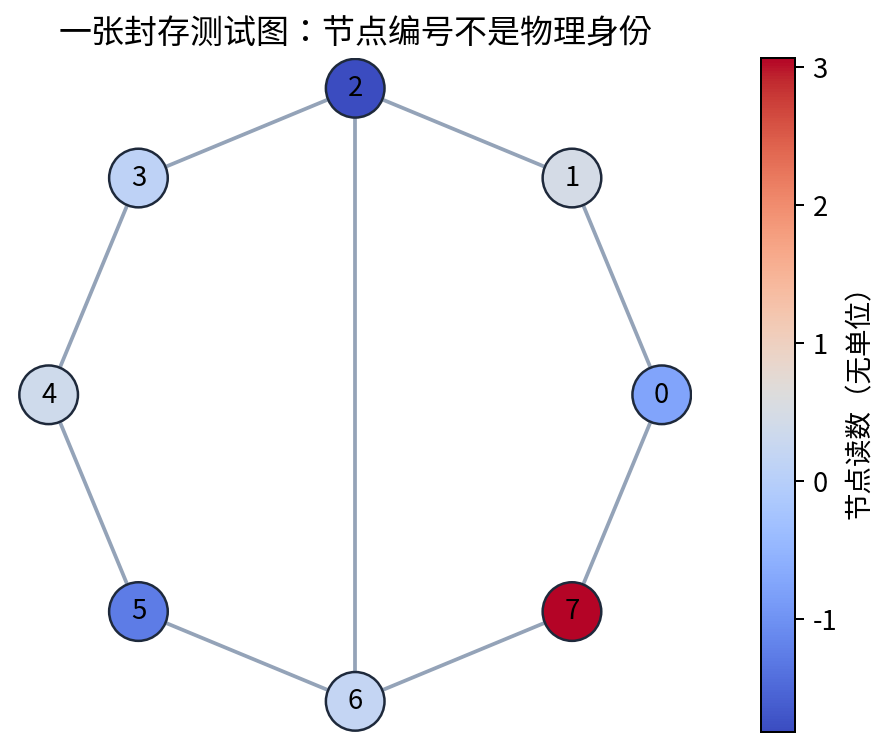

In [7]:
from IPython.display import display, Image
# 图由课程参考outputs重建，这里核验Notebook图像显示。
figure=sorted(Path("figures").glob("*.png"))[0]
display(Image(filename=str(figure),width=640))